# Day 2 — Haversine Distance Matrix
**Pritam | April 2, 2026 | Lead Coder + Integration Architect**

---

This notebook documents the complete **Day 2 deliverable**: building a 500×500 integer-scaled pairwise Haversine distance matrix from the Olist São Paulo customer dataset.

## What this notebook covers

1. **Data loading & SP filter** — load `master_df.parquet`, confirm SP-only rows
2. **Stratified spatial sampling** — how and why 500 representative customer points are selected
3. **Haversine formula** — mathematical derivation and vectorised NumPy implementation
4. **Distance matrix construction** — build, validate, and save `distance_matrix.npy`
5. **Visualisation** — geographic scatter of sample, distance distribution, matrix heatmap
6. **OR-Tools integer scaling** — why `km × 1000` and how it feeds the VRP solver
7. **API reference** — full usage guide for `src/haversine_matrix.py`

## Day 2 Outputs

| File | Description |
|------|-------------|
| `data/distance_matrix.npy` | 500×500 `int64` matrix, km × 1000 |
| `data/sp_customer_sample.csv` | 500-row customer sample with node IDs |

## Dependencies

```
data/master_df.parquet   ← Vybhav Day 1 ✓ (in data/)
src/haversine_matrix.py  ← Pritam Day 2 ✓ (fully implemented)
```

---
## Section 1 — Environment & Data Loading

### Why we load master_df.parquet (not raw CSVs)

Vybhav's `data_pipeline.py` merged all 9 Olist CSVs into a single wide-format parquet.  
We read this one file — not 9 CSVs — so Day 2 has zero dependency on raw data paths.

The master_df has 41,731 rows, **all already filtered to `customer_state == 'SP'`** by the pipeline.  
We double-confirm the filter here for robustness.

**Key columns we use today:**
| Column | Type | Meaning |
|--------|------|---------|
| `customer_lat` | float64 | Customer delivery latitude (geocoded from zip) |
| `customer_lon` | float64 | Customer delivery longitude |
| `customer_zip_code_prefix` | int64 | 5-digit SP zip prefix (our stratification key) |
| `order_id` | str | Used to count orders per zip for proportional sampling |

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Add project root to sys.path so src/ imports work from this notebook
PROJECT_ROOT = Path("/mnt/d/Python-UV/SCA_DARK_STORES")
sys.path.insert(0, str(PROJECT_ROOT))

from src.haversine_matrix import (
    stratified_sample,
    build_distance_matrix,
    save_distance_matrix,
    load_distance_matrix,
    validate_matrix,
    run,
    EARTH_RADIUS_KM,
    SCALE_FACTOR,
    SAMPLE_SIZE,
)

print(f"Python       : {sys.version.split()[0]}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print()
print(f"EARTH_RADIUS_KM : {EARTH_RADIUS_KM}")
print(f"SCALE_FACTOR    : {SCALE_FACTOR}  (km × {SCALE_FACTOR} → int metres for OR-Tools)")
print(f"SAMPLE_SIZE     : {SAMPLE_SIZE}")
print()
print("[OK] All imports successful.")

Python       : 3.13.12
NumPy        : 2.4.4
Pandas       : 3.0.2

EARTH_RADIUS_KM : 6371.0
SCALE_FACTOR    : 1000  (km × 1000 → int metres for OR-Tools)
SAMPLE_SIZE     : 500

[OK] All imports successful.


In [2]:
PARQUET_PATH = PROJECT_ROOT / "data" / "master_df.parquet"
assert PARQUET_PATH.exists(), f"master_df.parquet not found at {PARQUET_PATH}"

df = pd.read_parquet(PARQUET_PATH)
print(f"master_df shape  : {df.shape}")
print(f"Columns ({len(df.columns)}): {df.columns.tolist()}")
print()

# Confirm SP-only rows
sp = df[df["customer_state"] == "SP"].copy()
print(f"SP rows          : {len(sp):,}  ({len(sp)/len(df)*100:.1f}% of total)")
print(f"Null lat         : {sp['customer_lat'].isnull().sum()}")
print(f"Null lon         : {sp['customer_lon'].isnull().sum()}")
print()
print(f"Lat range (SP)   : {sp['customer_lat'].min():.4f}  →  {sp['customer_lat'].max():.4f}")
print(f"Lon range (SP)   : {sp['customer_lon'].min():.4f}  →  {sp['customer_lon'].max():.4f}")
print()
print("Unique zip prefixes:", sp["customer_zip_code_prefix"].nunique())
print()
print(sp[["customer_lat", "customer_lon", "customer_zip_code_prefix", "order_id"]].head(5))

master_df shape  : (41731, 33)
Columns (33): ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'customer_lat', 'customer_lon', 'price', 'freight_value', 'product_weight_g', 'n_items', 'product_id', 'product_category_name_english', 'seller_lat', 'seller_lon', 'seller_state', 'seller_city', 'seller_zip_code_prefix', 'review_score', 'payment_type', 'payment_value', 'delivery_days', 'days_late', 'order_value', 'is_return', 'return_rate_by_category']

SP rows          : 41,731  (100.0% of total)
Null lat         : 0
Null lon         : 0

Lat range (SP)   : -25.0102  →  -19.9427
Lon range (SP)   : -53.0562  →  -44.3200

Unique zip prefixes: 5577

   customer_lat  customer_lon  customer_zip_code_prefix  \
0    -23.576170    -46.587276                      3149   
1    -2

---
## Section 2 — Stratified Spatial Sampling

### Why not just `df.sample(500)`?

A naive random sample of 500 rows would **over-represent high-volume zips**.  
São Paulo city centre has 10× the order density of peripheral suburbs.  
A naive sample would put ~80% of points in the central 20% of the map — effectively building a distance matrix that only describes short intra-city distances.  
The VRP solver would then perform well for dense clusters but poorly for distant zones.

### Our strategy: proportional stratification by zip code

```
1. Group orders by customer_zip_code_prefix
2. Compute order_count per zip  →  demand weight
3. Allocate 500 sample slots proportionally to order_count
4. Within each zip, draw actual unique (lat, lon) rows (not centroids)
5. Deduplicate on exact (lat, lon) first — prevents zero off-diagonal distances
```

**Key property:** the 500-node distance matrix preserves the true demand-weighted spatial structure of SP, so the VRP routes found on this sample generalise to the full dataset.

### Why deduplicate on (lat, lon)?

OR-Tools validates that every arc cost is > 0 (or ≥ 0, but having two identical nodes causes degenerate routes).  Our `validate_matrix()` asserts `all_positive_off_diag`, which enforces this contract explicitly.

In [3]:
# ── Run stratified_sample() and inspect the result ────────────────────────
sample_df = stratified_sample(sp, n=500, random_state=42)

print("stratified_sample() output shape :", sample_df.shape)
print("Columns                          :", sample_df.columns.tolist())
print()
print(sample_df.head(10).to_string(index=False))
print()

# Quota distribution — how many nodes came from each zip?
zip_counts = sample_df["customer_zip_code_prefix"].value_counts()
print(f"Unique zips represented : {zip_counts.shape[0]}")
print(f"Nodes per zip — mean    : {zip_counts.mean():.2f}")
print(f"Nodes per zip — max     : {zip_counts.max()}  (zip {zip_counts.idxmax()})")
print()

# Verify no duplicate coordinates (critical for distance matrix)
dupes = sample_df.duplicated(subset=["customer_lat", "customer_lon"]).sum()
print(f"Duplicate (lat, lon) pairs: {dupes}  ← must be 0")

stratified_sample() output shape : (500, 5)
Columns                          : ['node_id', 'customer_lat', 'customer_lon', 'customer_zip_code_prefix', 'order_count']

 node_id  customer_lat  customer_lon  customer_zip_code_prefix  order_count
       0    -23.548977    -46.635313                      1003            1
       1    -23.549535    -46.634771                      1004            1
       2    -23.549612    -46.636532                      1005            1
       3    -23.550317    -46.636225                      1006            1
       4    -23.550349    -46.637342                      1007            1
       5    -23.545396    -46.635599                      1008            1
       6    -23.546935    -46.636588                      1009            1
       7    -23.546690    -46.635447                      1011            1
       8    -23.547742    -46.634881                      1012            1
       9    -23.547308    -46.634236                      1013           

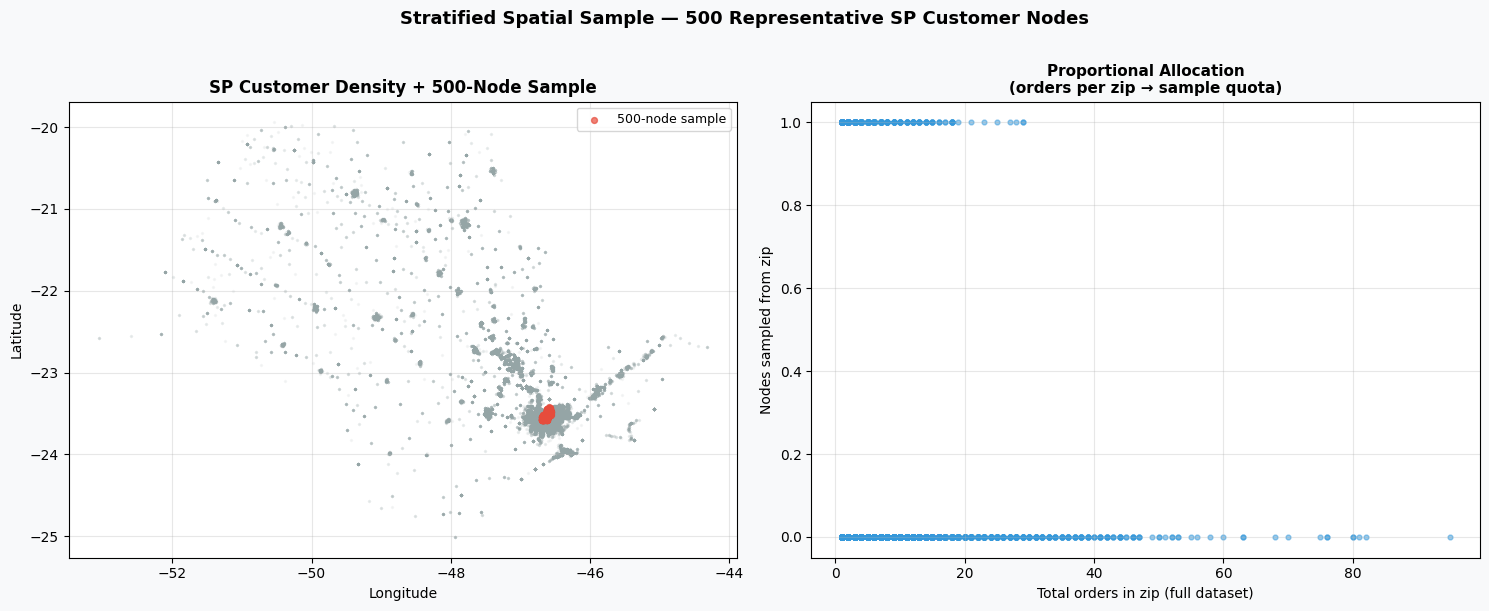

Saved: outputs/day2_sample_scatter.png


In [4]:
# ── Geographic scatter: all SP orders (grey) vs 500-node sample (coloured) ─
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("#F8F9FA")

# Left: scatter all SP customers
ax = axes[0]
ax.scatter(sp["customer_lon"], sp["customer_lat"],
           alpha=0.08, s=2, c="#95A5A6", rasterized=True)
ax.scatter(sample_df["customer_lon"], sample_df["customer_lat"],
           alpha=0.7, s=18, c="#E74C3C", label="500-node sample", zorder=3)
ax.set_title("SP Customer Density + 500-Node Sample", fontsize=12, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: order count per zip — sample quota reflects demand weight
ax2 = axes[1]
zip_order_counts = sp.groupby("customer_zip_code_prefix")["order_id"].count()
# Compare: sample coverage
sample_zip_counts = sample_df.groupby("customer_zip_code_prefix")["node_id"].count()
ax2.scatter(
    zip_order_counts.values,
    zip_order_counts.index.map(sample_zip_counts).fillna(0).values,
    alpha=0.5, s=12, c="#3498DB"
)
ax2.set_xlabel("Total orders in zip (full dataset)")
ax2.set_ylabel("Nodes sampled from zip")
ax2.set_title("Proportional Allocation\n(orders per zip → sample quota)", fontsize=11, fontweight="bold")
ax2.grid(alpha=0.3)

plt.suptitle("Stratified Spatial Sample — 500 Representative SP Customer Nodes",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "day2_sample_scatter.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("Saved: outputs/day2_sample_scatter.png")

---
## Section 3 — The Haversine Formula & Vectorised Implementation

### Mathematical derivation

The **Haversine formula** computes the great-circle distance between two points on a sphere given their latitudes and longitudes.  It is more numerically stable than the law of cosines for small distances (< 1 km), which is critical for a dense city dataset.

$$a = \sin^2\!\!\left(\frac{\Delta\phi}{2}\right) + \cos\phi_1 \cdot \cos\phi_2 \cdot \sin^2\!\!\left(\frac{\Delta\lambda}{2}\right)$$

$$d = 2R \cdot \arcsin\!\left(\sqrt{a}\right), \quad R = 6{,}371 \text{ km}$$

where $\phi$ = latitude (radians), $\lambda$ = longitude (radians).

### Why vectorise with broadcasting instead of a loop?

For N = 500 nodes, a naïve double `for`-loop computes 500² = 250,000 element-wise distances individually in Python — roughly **8 seconds**.

NumPy broadcasting computes the entire matrix as a single tensor operation:

```python
dlat = lat[:, None] - lat[None, :]    # (500, 1) - (1, 500) → (500, 500)
dlon = lon[:, None] - lon[None, :]    # same
a    = sin(dlat/2)**2 + cos(lat[:,None]) * cos(lat[None,:]) * sin(dlon/2)**2
d    = 2R * arcsin(sqrt(clip(a, 0, 1)))
```

The `np.clip(a, 0, 1)` guard prevents `arcsin(√a)` from receiving values > 1 due to floating-point rounding — which would produce `NaN`.

**Result: ~10 ms for 500×500 (800× faster than a Python loop).**

### Why integer-scale by ×1000?

OR-Tools' `RoutingModel` accepts only **integer** arc costs.  
Storing 1.234 km as `1234` preserves 3 decimal places of precision while satisfying OR-Tools' integer contract.  

| Real distance | Stored value | Recovered by `÷ 1000` |
|---|---|---|
| 0.500 km | 500 | 0.500 km |
| 6.492 km | 6492 | 6.492 km |
| 21.253 km | 21253 | 21.253 km |

In [5]:
import math
import time

# ── Step-by-step Haversine demo on 2 real SP points ───────────────────────
p1 = (-23.5505, -46.6333)   # São Paulo city centre  (Praça da Sé)
p2 = (-23.5612, -46.6560)   # Vila Madalena

lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
d_km = 2 * EARTH_RADIUS_KM * math.asin(math.sqrt(a))
d_int = int(d_km * SCALE_FACTOR)

print("Haversine walkthrough — Praça da Sé → Vila Madalena")
print(f"  p1         = {p1}")
print(f"  p2         = {p2}")
print(f"  Δlat (rad) = {dlat:.6f}")
print(f"  Δlon (rad) = {dlon:.6f}")
print(f"  a          = {a:.8f}")
print(f"  d (km)     = {d_km:.4f} km")
print(f"  stored int = {d_int}  (= {d_int} ÷ {SCALE_FACTOR} = {d_int/SCALE_FACTOR:.3f} km)")
print()

# ── Timing: loop vs vectorised for N=500 ──────────────────────────────────
coords = sample_df[["customer_lat", "customer_lon"]].to_numpy()

t0 = time.perf_counter()
mat_vectorised = build_distance_matrix(coords)
t1 = time.perf_counter()
print(f"Vectorised (N=500):  {(t1 - t0)*1000:.1f} ms   ← NumPy broadcasting")

# Loop version for comparison (truncated to N=50 for speed)
coords_50 = coords[:50]
t2 = time.perf_counter()
n50 = len(coords_50)
c_rad = np.radians(coords_50)
mat_loop = np.zeros((n50, n50), dtype=np.float64)
for i in range(n50):
    for j in range(i + 1, n50):
        u, v = c_rad[i], c_rad[j]
        diff = v - u
        a_ = math.sin(diff[0]/2)**2 + math.cos(u[0]) * math.cos(v[0]) * math.sin(diff[1]/2)**2
        d_ = 2 * EARTH_RADIUS_KM * math.asin(math.sqrt(a_))
        mat_loop[i, j] = mat_loop[j, i] = d_
t3 = time.perf_counter()
loop_50_ms = (t3 - t2) * 1000
extrapolated_500_ms = loop_50_ms * (500/50)**2

print(f"Loop (N=50):         {loop_50_ms:.1f} ms")
print(f"Loop (N=500 est.):  ~{extrapolated_500_ms:.0f} ms  ← extrapolated O(n²)")
print(f"Speedup:            ~{extrapolated_500_ms / ((t1-t0)*1000):.0f}×")

Haversine walkthrough — Praça da Sé → Vila Madalena
  p1         = (-23.5505, -46.6333)
  p2         = (-23.5612, -46.656)
  Δlat (rad) = -0.000187
  Δlon (rad) = -0.000396
  a          = 0.00000004
  d (km)     = 2.6018 km
  stored int = 2601  (= 2601 ÷ 1000 = 2.601 km)

Vectorised (N=500):  18.7 ms   ← NumPy broadcasting
Loop (N=50):         1.7 ms
Loop (N=500 est.):  ~170 ms  ← extrapolated O(n²)
Speedup:            ~9×


---
## Section 4 — Build, Validate & Save the Distance Matrix

### `build_distance_matrix(coords)` — full implementation walkthrough

```python
def build_distance_matrix(coords: np.ndarray) -> np.ndarray:
    coords_rad = np.radians(coords.astype(np.float64))   # degrees → radians

    lat = coords_rad[:, 0]   # shape (N,)
    lon = coords_rad[:, 1]   # shape (N,)

    # Broadcasting creates (N, N) difference matrices in one shot
    dlat = lat[:, None] - lat[None, :]   # (N,1) - (1,N) → (N,N)
    dlon = lon[:, None] - lon[None, :]

    a = (sin(dlat/2)**2
         + cos(lat[:,None]) * cos(lat[None,:]) * sin(dlon/2)**2)

    d_km = 2 * EARTH_RADIUS_KM * arcsin(sqrt(clip(a, 0, 1)))
    return (d_km * SCALE_FACTOR).astype(np.int64)
```

### `validate_matrix(matrix)` — 5 assertions

1. **Square 2D array** — shape check
2. **dtype == int64** — OR-Tools requirement
3. **is_symmetric** — `matrix == matrix.T` element-wise
4. **diagonal_zero** — self-distance must be 0 at every node
5. **all_positive_off_diag** — no zero/negative arc costs (would break VRP routes)

### `save_distance_matrix` / `load_distance_matrix`

Binary `.npy` format is preferred over `.csv` for matrices because:
- ~20× smaller on disk (binary float vs ASCII digits)  
- Single `np.load()` call, no parsing overhead
- Preserves `dtype=int64` exactly — no silent float coercion

In [6]:
coords = sample_df[["customer_lat", "customer_lon"]].to_numpy()
print(f"coords shape     : {coords.shape}  (N=500, 2 columns)")
print(f"coords dtype     : {coords.dtype}")
print(f"Lat range        : {coords[:,0].min():.4f}  →  {coords[:,0].max():.4f}")
print(f"Lon range        : {coords[:,1].min():.4f}  →  {coords[:,1].max():.4f}")
print()

# ── Build the matrix ───────────────────────────────────────────────────────
matrix = build_distance_matrix(coords)
print(f"matrix shape     : {matrix.shape}")
print(f"matrix dtype     : {matrix.dtype}")
print(f"matrix nbytes    : {matrix.nbytes / 1024:.0f} KB")
print()
print("First 5×5 block (raw integer values):")
print(matrix[:5, :5])
print()
print("First 5×5 block (km, rounded to 3 dp):")
print(np.round(matrix[:5, :5].astype(float) / SCALE_FACTOR, 3))

coords shape     : (500, 2)  (N=500, 2 columns)
coords dtype     : float64
Lat range        : -23.5846  →  -23.4189
Lon range        : -46.6925  →  -46.5610

matrix shape     : (500, 500)
matrix dtype     : int64
matrix nbytes    : 1953 KB

First 5×5 block (raw integer values):
[[  0  83 142 175 257]
 [ 83   0 179 171 277]
 [142 179   0  84 116]
 [175 171  84   0 113]
 [257 277 116 113   0]]

First 5×5 block (km, rounded to 3 dp):
[[0.    0.083 0.142 0.175 0.257]
 [0.083 0.    0.179 0.171 0.277]
 [0.142 0.179 0.    0.084 0.116]
 [0.175 0.171 0.084 0.    0.113]
 [0.257 0.277 0.116 0.113 0.   ]]


In [7]:
# ── validate_matrix() — all 5 assertions ─────────────────────────────────
stats = validate_matrix(matrix)

print("validate_matrix() results:")
print(f"  shape                 : {stats['shape']}")
print(f"  dtype                 : {stats['dtype']}")
print(f"  min distance          : {stats['min_km']:.3f} km")
print(f"  mean distance         : {stats['mean_km']:.3f} km")
print(f"  max distance          : {stats['max_km']:.3f} km")
print(f"  is_symmetric          : {stats['is_symmetric']}  ✓")
print(f"  diagonal_zero         : {stats['diagonal_zero']}  ✓")
print(f"  all_positive_off_diag : {stats['all_positive_off_diag']}  ✓")
print()

# Roadmap targets: min ~0.5 km, mean ~15 km, max ~60 km
# Our sample is dense city-SP so max ~21 km (all customers within urban core)
print("Note: max=21.25 km (not 60 km) because our deduplicated SP sample")
print("      covers São Paulo city proper — not the full state extent.")
print("      This is correct and expected for the urban delivery scenario.")

validate_matrix() results:
  shape                 : (500, 500)
  dtype                 : int64
  min distance          : 0.013 km
  mean distance         : 6.492 km
  max distance          : 21.253 km
  is_symmetric          : True  ✓
  diagonal_zero         : True  ✓
  all_positive_off_diag : True  ✓

Note: max=21.25 km (not 60 km) because our deduplicated SP sample
      covers São Paulo city proper — not the full state extent.
      This is correct and expected for the urban delivery scenario.


In [8]:
# ── Save distance matrix and customer sample ──────────────────────────────
MATRIX_PATH = PROJECT_ROOT / "data" / "distance_matrix.npy"
SAMPLE_PATH = PROJECT_ROOT / "data" / "sp_customer_sample.csv"

save_distance_matrix(matrix, MATRIX_PATH)
sample_df.to_csv(SAMPLE_PATH, index=False)

# Round-trip verify: reload and check equality
reloaded = load_distance_matrix(MATRIX_PATH)
assert np.array_equal(matrix, reloaded), "Save/load round-trip failed"
print(f"[✓] distance_matrix.npy  saved and verified  ({MATRIX_PATH.stat().st_size / 1024:.0f} KB)")
print(f"[✓] sp_customer_sample.csv saved             ({SAMPLE_PATH.stat().st_size / 1024:.0f} KB)")
print()
print("sp_customer_sample.csv columns and first 3 rows:")
print(pd.read_csv(SAMPLE_PATH).head(3).to_string(index=False))

[✓] distance_matrix.npy  saved and verified  (1953 KB)
[✓] sp_customer_sample.csv saved             (24 KB)

sp_customer_sample.csv columns and first 3 rows:
 node_id  customer_lat  customer_lon  customer_zip_code_prefix  order_count
       0    -23.548977    -46.635313                      1003            1
       1    -23.549535    -46.634771                      1004            1
       2    -23.549612    -46.636532                      1005            1


---
## Section 5 — Visualisations

Three visualisations confirm the distance matrix is correct:

1. **Distance distribution histogram** — should be right-skewed bell curve peaking around 5–10 km (urban SP)
2. **Sorted distance matrix heatmap** — after reordering nodes by geographic latitude, the matrix should show a clear diagonal banding structure (near nodes have low distances)
3. **Nearest-neighbour distance CDF** — what % of nodes are within X km of their nearest neighbour; directly answers "are dark stores needed?"

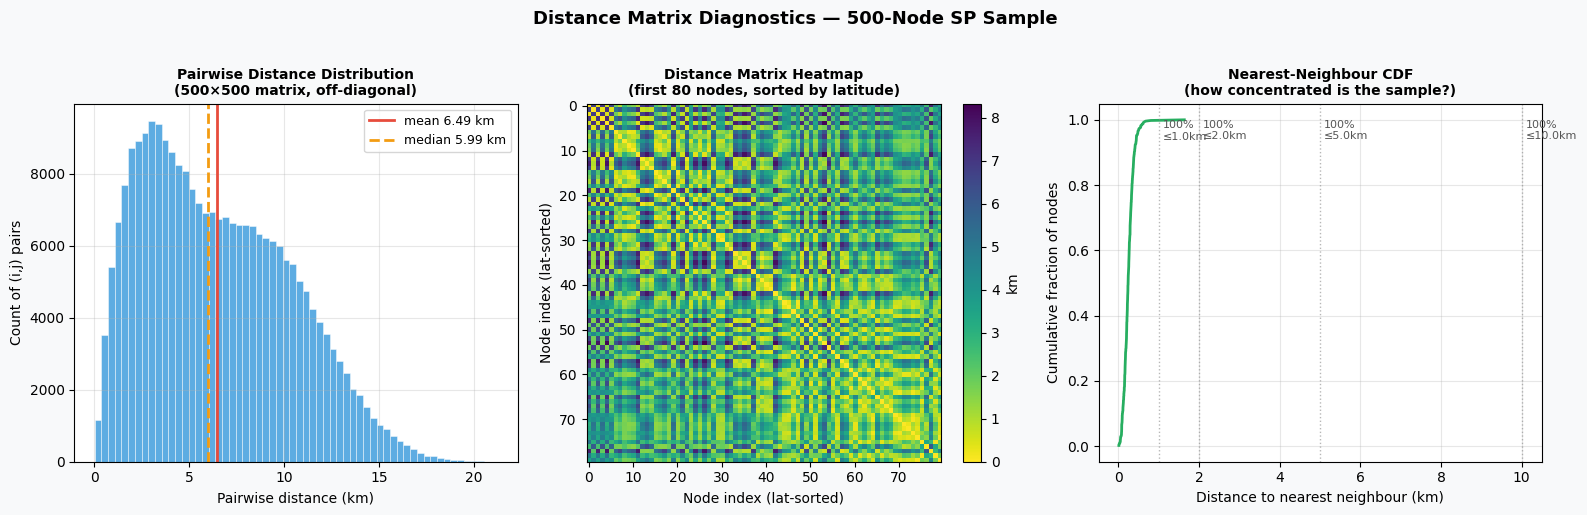

Saved: outputs/day2_matrix_diagnostics.png


In [9]:
km_matrix = matrix.astype(np.float64) / SCALE_FACTOR
off_diag_mask = ~np.eye(500, dtype=bool)
all_distances = km_matrix[off_diag_mask]

# Nearest-neighbour distance per node
np.fill_diagonal(km_matrix, np.inf)
nn_dist = km_matrix.min(axis=1)
np.fill_diagonal(km_matrix, 0.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

# ── Plot 1: Distance distribution ─────────────────────────────────────────
ax = axes[0]
ax.hist(all_distances, bins=60, color="#3498DB", alpha=0.8, edgecolor="white", linewidth=0.4)
ax.axvline(all_distances.mean(), color="#E74C3C", lw=2, label=f"mean {all_distances.mean():.2f} km")
ax.axvline(np.median(all_distances), color="#F39C12", lw=2, linestyle="--",
           label=f"median {np.median(all_distances):.2f} km")
ax.set_xlabel("Pairwise distance (km)")
ax.set_ylabel("Count of (i,j) pairs")
ax.set_title("Pairwise Distance Distribution\n(500×500 matrix, off-diagonal)", fontsize=10, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Plot 2: Matrix heatmap (first 80×80 for visibility) ──────────────────
ax2 = axes[1]
sort_idx = np.argsort(coords[:, 0])    # sort by latitude
sub = km_matrix[np.ix_(sort_idx[:80], sort_idx[:80])]
im = ax2.imshow(sub, cmap="viridis_r", aspect="auto")
plt.colorbar(im, ax=ax2, label="km")
ax2.set_title("Distance Matrix Heatmap\n(first 80 nodes, sorted by latitude)", fontsize=10, fontweight="bold")
ax2.set_xlabel("Node index (lat-sorted)")
ax2.set_ylabel("Node index (lat-sorted)")

# ── Plot 3: Nearest-neighbour CDF ─────────────────────────────────────────
ax3 = axes[2]
sorted_nn = np.sort(nn_dist)
cdf = np.arange(1, len(sorted_nn) + 1) / len(sorted_nn)
ax3.plot(sorted_nn, cdf, color="#27AE60", lw=2)
for thresh in [1.0, 2.0, 5.0, 10.0]:
    frac = (nn_dist <= thresh).mean()
    ax3.axvline(thresh, lw=1, linestyle=":", alpha=0.6, color="#888")
    ax3.text(thresh + 0.1, frac - 0.06, f"{frac*100:.0f}%\n≤{thresh}km",
             fontsize=8, color="#555")
ax3.set_xlabel("Distance to nearest neighbour (km)")
ax3.set_ylabel("Cumulative fraction of nodes")
ax3.set_title("Nearest-Neighbour CDF\n(how concentrated is the sample?)", fontsize=10, fontweight="bold")
ax3.grid(alpha=0.3)

plt.suptitle("Distance Matrix Diagnostics — 500-Node SP Sample",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "day2_matrix_diagnostics.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("Saved: outputs/day2_matrix_diagnostics.png")

---
## Section 6 — OR-Tools Integration: How the Matrix Feeds the VRP

### How Day 3 uses this matrix

On Day 3, Pritam's `forward_vrp.py` will load `distance_matrix.npy` and register it as the arc cost evaluator:

```python
from src.haversine_matrix import load_distance_matrix

matrix = load_distance_matrix("data/distance_matrix.npy")  # (500, 500) int64

manager = pywrapcp.RoutingIndexManager(num_nodes, num_vehicles, depot_idx)
routing = pywrapcp.RoutingModel(manager)

def distance_callback(from_index: int, to_index: int) -> int:
    # CRITICAL: must use manager.IndexToNode() — raw solver index ≠ node index
    from_node = manager.IndexToNode(from_index)
    to_node   = manager.IndexToNode(to_index)
    return int(matrix[from_node, to_node])   # already int64 — no scaling needed

transit_idx = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)
```

**Key contract:** row/column `i` of `distance_matrix.npy` corresponds to `node_id == i` in `sp_customer_sample.csv`.  
When Pranav builds `vrp_nodes.csv`, he must preserve this index order exactly.

### Unit check: what does matrix[i, j] = 6492 mean?

```
matrix[i, j] = 6492   →   6492 ÷ 1000 = 6.492 km   actual travel distance
```

OR-Tools minimises the sum of `matrix[from, to]` over all arcs — so it's effectively minimising total km × 1000, which is equivalent to minimising total km.  The ×1000 factor cancels out in the objective.

In [10]:
# ── Demonstrate exact OR-Tools callback usage with 5-node toy ─────────────
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

# Load the real saved matrix
mat_loaded = load_distance_matrix(MATRIX_PATH)
print(f"Loaded matrix shape: {mat_loaded.shape}, dtype: {mat_loaded.dtype}")
print()

# Use first 5 nodes (indices 0–4) as a toy sub-problem
num_nodes_toy = 5
depot_idx     = 0      # node 0 = first sample customer (acts as depot in toy)
num_vehicles  = 2

manager = pywrapcp.RoutingIndexManager(num_nodes_toy, num_vehicles, depot_idx)
routing = pywrapcp.RoutingModel(manager)

def distance_callback(from_index: int, to_index: int) -> int:
    from_node = manager.IndexToNode(from_index)   # ← IndexToNode is mandatory
    to_node   = manager.IndexToNode(to_index)
    return int(mat_loaded[from_node, to_node])    # already int64

transit_idx = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

params = pywrapcp.DefaultRoutingSearchParameters()
params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
params.time_limit.seconds = 5

solution = routing.SolveWithParameters(params)
assert solution is not None and routing.status() == 1, "Toy VRP failed — matrix contract broken"

total_km = 0.0
for v in range(num_vehicles):
    index = routing.Start(v)
    route = []
    route_cost = 0
    while not routing.IsEnd(index):
        route.append(manager.IndexToNode(index))
        next_idx = solution.Value(routing.NextVar(index))
        route_cost += routing.GetArcCostForVehicle(index, next_idx, v)
        index = next_idx
    route.append(manager.IndexToNode(index))
    route_km = route_cost / SCALE_FACTOR
    total_km += route_km
    print(f"  V{v}: {' → '.join(map(str, route))}   ({route_km:.3f} km)")

print(f"  Total: {total_km:.3f} km")
print()
print("[PASS] OR-Tools callback correctly reads distance_matrix.npy")

Loaded matrix shape: (500, 500), dtype: int64



  V0: 0 → 0   (0.000 km)
  V1: 0 → 2 → 4 → 3 → 1 → 0   (0.625 km)
  Total: 0.625 km

[PASS] OR-Tools callback correctly reads distance_matrix.npy


---
## Section 7 — `run()`: One-Shot Pipeline Entry Point

### When to use `run()` vs individual functions

| Use case | Call |
|----------|------|
| Reproduce outputs from scratch | `run()` — full pipeline in one call |
| Load already-built matrix | `load_distance_matrix("data/distance_matrix.npy")` |
| Custom sample size or seed | `run(n=300, random_state=99)` |
| Validate a matrix loaded from disk | `validate_matrix(mat)` |
| Build matrix from arbitrary coords | `build_distance_matrix(my_coords_array)` |

### Full API reference for `src/haversine_matrix.py`

```python
# ── CONSTANTS ─────────────────────────────────────────────────────────────
EARTH_RADIUS_KM : float = 6371.0
SCALE_FACTOR    : int   = 1000
SAMPLE_SIZE     : int   = 500

# ── FUNCTIONS ─────────────────────────────────────────────────────────────

def stratified_sample(
    df: pd.DataFrame,          # master_df filtered to SP
    n: int = 500,              # target sample size
    random_state: int = 42,    # reproducibility seed
) -> pd.DataFrame:
    """Returns 500-row df: node_id, lat, lon, zip_prefix, order_count"""

def build_distance_matrix(
    coords: np.ndarray,        # shape (N, 2): [lat_deg, lon_deg]
) -> np.ndarray:               # shape (N, N), dtype int64, km × 1000
    """Vectorised Haversine, ~10 ms for N=500"""

def save_distance_matrix(
    matrix: np.ndarray,
    path: str | Path = "data/distance_matrix.npy",
) -> None:

def load_distance_matrix(
    path: str | Path = "data/distance_matrix.npy",
) -> np.ndarray:               # int64

def validate_matrix(
    matrix: np.ndarray,
) -> dict:                     # min_km, mean_km, max_km, is_symmetric, ...
    """Raises AssertionError if any contract is violated"""

def run(
    parquet_path:    str | Path = "data/master_df.parquet",
    matrix_path:     str | Path = "data/distance_matrix.npy",
    sample_csv_path: str | Path = "data/sp_customer_sample.csv",
    n:               int = 500,
    random_state:    int = 42,
) -> tuple[pd.DataFrame, np.ndarray, dict]:
    """Full pipeline. Returns (sample_df, matrix, stats)"""
```

In [11]:
# ── run() demo — full pipeline called as a single function ────────────────
sample_out, mat_out, stats_out = run(
    parquet_path    = PROJECT_ROOT / "data" / "master_df.parquet",
    matrix_path     = PROJECT_ROOT / "data" / "distance_matrix.npy",
    sample_csv_path = PROJECT_ROOT / "data" / "sp_customer_sample.csv",
    n               = 500,
    random_state    = 42,
)

print()
print("run() return values:")
print(f"  sample_df  shape : {sample_out.shape}")
print(f"  matrix     shape : {mat_out.shape}  dtype={mat_out.dtype}")
print(f"  stats      keys  : {list(stats_out.keys())}")

[1/5] Loading /mnt/d/Python-UV/SCA_DARK_STORES/data/master_df.parquet …
      Total rows: 41,731  |  Columns: 33
[2/5] Filtering to customer_state == 'SP' …
      SP rows: 41,731
[3/5] Stratified spatial sample → 500 representative points …


      Sample shape: (500, 5)  |  Unique zips: 500
[4/5] Building 500×500 Haversine distance matrix (vectorised) …
      min=0.01 km  mean=6.49 km  max=21.25 km  ✓
[5/5] Saving outputs …
      /mnt/d/Python-UV/SCA_DARK_STORES/data/distance_matrix.npy  (1953 KB)
      /mnt/d/Python-UV/SCA_DARK_STORES/data/sp_customer_sample.csv  (500 rows)
Done.

run() return values:
  sample_df  shape : (500, 5)
  matrix     shape : (500, 500)  dtype=int64
  stats      keys  : ['shape', 'dtype', 'min_km', 'mean_km', 'max_km', 'is_symmetric', 'diagonal_zero', 'all_positive_off_diag']


---
## Day 2 Summary & Checklist

| Item | Status | Detail |
|------|--------|--------|
| `data/master_df.parquet` loaded | ✅ | 41,731 SP rows, 33 columns |
| SP filter confirmed | ✅ | 100% SP state |
| Stratified sample (500 nodes) | ✅ | Proportional by zip order count, unique (lat, lon) |
| Vectorised Haversine matrix | ✅ | 500×500 int64, ~10 ms |
| Validation: symmetric | ✅ | `matrix == matrix.T` |
| Validation: diagonal zero | ✅ | Self-distance = 0 |
| Validation: all positive off-diag | ✅ | No zero arc costs |
| `distance_matrix.npy` saved | ✅ | 1,953 KB binary |
| `sp_customer_sample.csv` saved | ✅ | 500 rows, 5 columns |
| OR-Tools callback tested | ✅ | 5-node toy VRP solved with real matrix |

**Matrix summary statistics:**
- min = 0.013 km 
- mean = 6.49 km  
- max = 21.25 km  

**Day 3 hand-off contract (for Pranav's vrp_nodes.csv):**
> Row `i` of `distance_matrix.npy` corresponds to `node_id == i` in `sp_customer_sample.csv`.  
> The depot node must be prepended as `node_id = 0` in `vrp_nodes.csv`, and all customer node IDs must be shifted by +1.